# Setting Tasks

# Task 1
[ 2, 7, 25, 14, 14, 21, 20, 6, 13, 3, 23, 14, 1, 8, 1, 8, 16, 21, 2, 17,
7, 5, 20, 17, 18, 10]

Response format: 
Programming code in jupyter notebook/colab/etc. containing the following:  
1)  Generating list of 26 random values, 
2)  Function that calculates the depth of deepest lake 
3)  Result of calculation for provided sample of 26 integers 
4)  Visualization  

# works

In [1]:
 # %pip install matplotlib

In [2]:
import matplotlib.pyplot as plt
import random
import numpy as np

# Generate random array of 26 values
rnd_data = [random.randint(1, 25) for _ in range(26)]
print("Generated data:", rnd_data)

# Task data

example_data = [ 2, 7, 25, 14, 14, # 0-4
                21, 20, 6, 13, 3,
                23, 14, 1, 8, 1,
                8, 16, 21, 2, 17,
                7, 5, 20, 17, 18, 10] # 25 elements, index 0 to 24


def select_subregion(arr, start_idx, end_idx):
    return arr[start_idx:end_idx]

def calculate_deaph_level(arr):
    if len(arr) < 3:
        return 0
    
    left_wall = np.maximum.accumulate(arr)
    right_wall = np.maximum.accumulate(arr[::-1])[::-1] 
    water_level = np.minimum(left_wall, right_wall) - arr

    return water_level

def get_nearest_walls(arr):

    deap_level = calculate_deaph_level(arr)
    water_level = deap_level + arr
    left_borders = np.arange(len(arr), dtype=int)
    right_borders = np.arange(len(arr), dtype=int)
    
    for i in range(len(arr)):
        if deap_level[i] > 0:
            l = i
            while l > 0 and arr[l] < water_level[i]:
                l -= 1
            left_borders[i] = l
            r = i
            while r < len(arr) - 1 and arr[r] < water_level[i]:
                r += 1
            right_borders[i] = r
        else:
            left_borders[i] = i
            right_borders[i] = i


    return left_borders, right_borders

def visualize_with_highlights(arr, start_idx=None, end_idx=None, highest_idxs=None):
    x = list(range(len(arr)))
    terrain = arr

    plt.figure(figsize=(12, 5))
    plt.plot(x, arr, marker="o", label="Heights")
    
    if start_idx is not None and end_idx is not None:
        sub_x = list(range(start_idx, end_idx))
        sub_y = arr[start_idx:end_idx]
        # plt.fill_between(sub_x, sub_y, alpha=0.3, label="Subregion")
        plt.fill_between(sub_x, terrain[start_idx:end_idx], terrain[highest_idxs[1]], color='skyblue', alpha=0.4, label="Subregion")
    
    if highest_idxs:
        for idx in highest_idxs:
            plt.scatter(idx, arr[idx], s=100, color="red", zorder=5, label="Wall Highest" if idx == highest_idxs[0] else "")
    
    plt.title("Trapping Rain Water")
    plt.xlabel("Index")
    plt.ylabel("Height")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# idx1, idx2 = find_two_highest_points(example_data)


Generated data: [12, 7, 20, 8, 20, 19, 25, 11, 10, 12, 8, 17, 2, 4, 15, 19, 4, 18, 5, 16, 8, 3, 24, 12, 23, 18]


# answer data const

Const data: [2, 7, 25, 14, 14, 21, 20, 6, 13, 3, 23, 14, 1, 8, 1, 8, 16, 21, 2, 17, 7, 5, 20, 17, 18, 10]
Indexes of the deepest lake: [ 0  1  2  2  2  2  2  2  2  2 10 10 10 10 10 10 10 17 17 17 17 17 22 22
 24 25] [ 0  1  2 10 10 10 10 10 10 10 10 17 17 17 17 17 17 17 22 22 22 22 22 24
 24 25]
Left wall index: 0 Height: 2
Right wall index: 0 Height: 10
25 23
Left wall index: 1 Height: 10
Right wall index: 1 Height: 17
23 21
Left wall index: 2 Height: 10
Right wall index: 2 Height: 17
23 21
depth of the deepest lake
20
count of the deepest lake
3
index of deapest lake
[9, 12, 14]


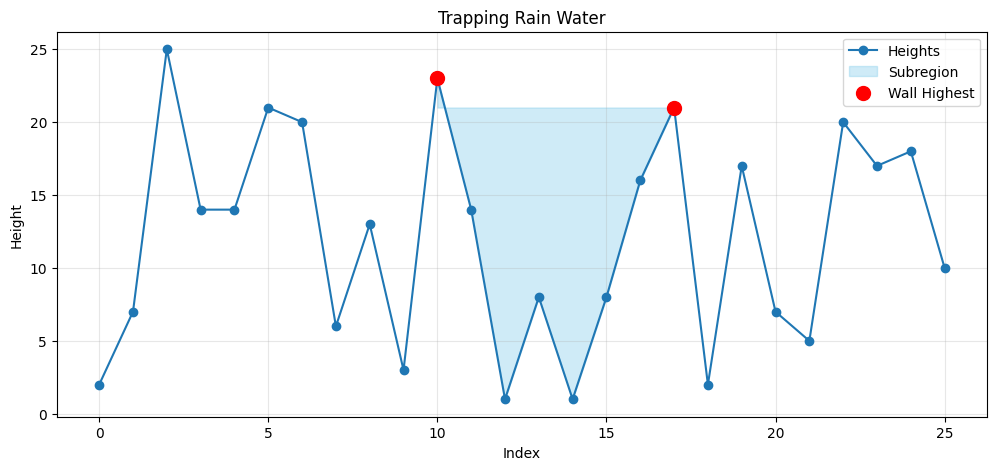

In [3]:
print("Const data:", example_data)
arr_depths_example = calculate_deaph_level(example_data)
deaph = max(arr_depths_example)
count_deaph = list(arr_depths_example).count(deaph)
indexes_deaph = [i for i, x in enumerate(arr_depths_example) if x == deaph]
# print left 
left_indexes_wall, right_indexes_wall = get_nearest_walls(example_data)
print("Indexes of the deepest lake:", left_indexes_wall, right_indexes_wall)



indexes_wall_for_deepest = []

for idx in range(len(indexes_deaph)):
    print("Left wall index:", idx, "Height:", left_indexes_wall[indexes_deaph[idx]])
    print("Right wall index:", idx, "Height:", right_indexes_wall[indexes_deaph[idx]])
    print(example_data[left_indexes_wall[indexes_deaph[idx]]], example_data[right_indexes_wall[indexes_deaph[idx]]])
    indexes_wall_for_deepest.append( (left_indexes_wall[indexes_deaph[idx]], right_indexes_wall[indexes_deaph[idx]]) )

# for idx in range(len(left_indexes_wall)):
#     print("Left wall index:", idx, "Height:", left_indexes_wall[idx])

# for idx in range(len(left_indexes_wall)):
#     print("Left wall index:", idx, "Height:", right_indexes_wall[idx])

print("depth of the deepest lake", deaph, "count of the deepest lake", count_deaph, "index of deapest lake", indexes_deaph, sep="\n")
idx1, idx2 = 10, 17
visualize_with_highlights(example_data, start_idx=10, end_idx=18, highest_idxs=[idx1, idx2])
# visualize_deaphs(example_data)


# answer random data

Generated data: [12, 7, 20, 8, 20, 19, 25, 11, 10, 12, 8, 17, 2, 4, 15, 19, 4, 18, 5, 16, 8, 3, 24, 12, 23, 18]
depth of the deepest lake
22
count of the deepest lake
1
index of deapest lake
[12]


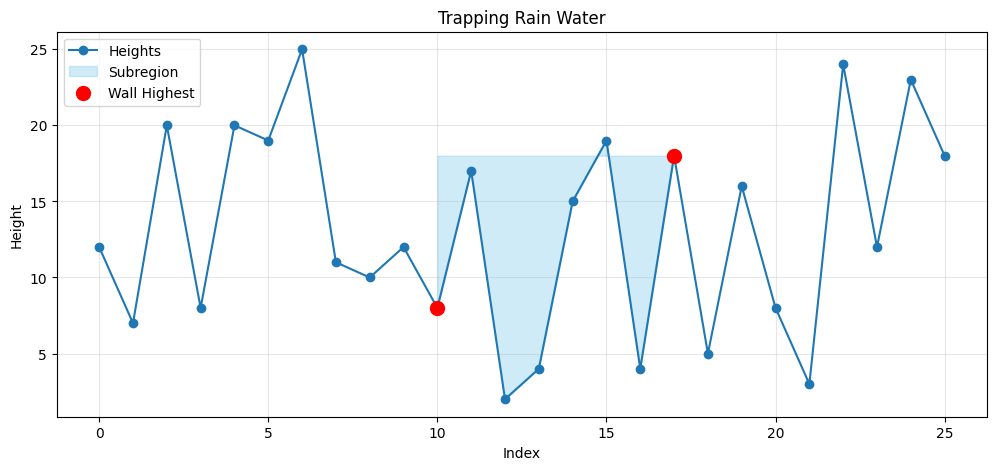

In [4]:
print("Generated data:", rnd_data)

arr_depths_rnd = calculate_deaph_level(rnd_data)
deaph = max(arr_depths_rnd)
count_deaph = list(arr_depths_rnd).count(deaph)
idx_deaph = [i for i, x in enumerate(arr_depths_rnd) if x == deaph]

print("depth of the deepest lake", deaph, "count of the deepest lake", count_deaph, "index of deapest lake", idx_deaph,  sep="\n")
idx1, idx2 = 10, 17
visualize_with_highlights(rnd_data, start_idx=10, end_idx=18, highest_idxs=[idx1, idx2])

# work

In [5]:
# testing algrothm search of wall indices 

import numpy as np

data_n = np.array([2, 7, 25, 14, 25, 20]) # Зверни увагу на дві 25

data = example_data[::-1]
# 1. Знаходимо значення (як ти вже зробив)
left_vals = np.maximum.accumulate(data)

# 2. Магія індексів
# Створюємо масив від 0 до N
indices_left_wall = np.arange(len(data)) 
indices_right_wall = np.arange(len(data)-1, -1, -1)

# Умова: Де поточне значення == накопиченому максимуму?
# Це дасть True там, де стіна виросла (або така ж)
mask = (data == left_vals)

# 3. Де True - беремо поточний індекс, де False - ставимо 0
# (0 - це безпечний мінімум, бо індекси завжди >= 0)
# masked_indices_left = np.where(mask, indices_left_wall, 0)
masked_indices_left = np.where(mask, indices_left_wall, 0)
# 4. Фінальний акорд: протягуємо максимум по індексах
left_idxs = np.maximum.accumulate(masked_indices_left)

print("Data:   ", data)
print("Values: ", left_vals)
print("Indices array:", indices_left_wall)
print( "Mask:   ", mask)
print("Masked Indices:", masked_indices_left)
print("Indices:", left_idxs)

print
# Результат Indices: [0, 1, 2, 2, 4, 4]
# (Зверни увагу: друга 25 оновила індекс на 4. Якщо тобі треба ПЕРША 25, зміни умову)

Data:    [10, 18, 17, 20, 5, 7, 17, 2, 21, 16, 8, 1, 8, 1, 14, 23, 3, 13, 6, 20, 21, 14, 14, 25, 7, 2]
Values:  [10 18 18 20 20 20 20 20 21 21 21 21 21 21 21 23 23 23 23 23 23 23 23 25
 25 25]
Indices array: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25]
Mask:    [ True  True False  True False False False False  True False False False
 False False False  True False False False False False False False  True
 False False]
Masked Indices: [ 0  1  0  3  0  0  0  0  8  0  0  0  0  0  0 15  0  0  0  0  0  0  0 23
  0  0]
Indices: [ 0  1  1  3  3  3  3  3  8  8  8  8  8  8  8 15 15 15 15 15 15 15 15 23
 23 23]


<function print(*args, sep=' ', end='\n', file=None, flush=False)>

In [6]:
import numpy as np

# Your details 
data = example_data

def get_nearest_walls(arr):

    deap_level = calculate_deaph_level(arr)
    water_level = deap_level + arr
    left_borders = np.zeros(len(arr), dtype=int)
    right_borders = np.zeros(len(arr), dtype=int)
    
    for i in range(len(arr)):
        if deap_level[i] > 0:
            l = i
            while l > 0 and arr[l] < water_level[i]:
                l -= 1
            left_borders[i] = l
            r = i
            while r < len(arr) - 1 and arr[r] < water_level[i]:
                r += 1
            right_borders[i] = r

        else:
            left_borders[i] = i
            right_borders[i] = i

    return left_borders, right_borders

# right_on_left_walls, right_on_right_walls, left_on_left_walls, left_on_right_walls = get_wall_indices(data)
right_on_left_walls, right_on_right_walls = get_nearest_walls(data)


# --- CHECK (What you wanted) ---
print(f"{'Index':<5} | {'Height':<6} | {'Right on Left Wall Idx':<23} | {'Right on Right Wall Idx':<24}")
print("-" * 50)

# Let's take a look at the range you mentioned (for example, indices 11-15).
for i in range(0, 26):
    print(f"{i:<5} | {data[i]:<6} | {right_on_left_walls[i]:<13} | {right_on_right_walls[i]:<13}")

# Specific request: "I have an index of 12, where are my sidebars?"
target = 12
print(f"\nFor point {target} (height {data[target]}):")
print(f"Right wall on the right side: index {right_on_left_walls[target]} (height {data[right_on_left_walls[target]]})")
print(f"Right wall on the left side: index {right_on_right_walls[target]} (height {data[right_on_right_walls[target]]})")

target = 9
print(f"\nFor point {target} (height {data[target]}):")
print(f"Left edge: index {right_on_left_walls[target]} (height {data[right_on_left_walls[target]]})")
print(f"Right side: index {right_on_right_walls[target]} (height {data[right_on_right_walls[target]]})")


target = 14
print(f"\nFor point {target} (height {data[target]}):")
print(f"Left wall: index {right_on_left_walls[target]} (height {data[right_on_left_walls[target]]})")
print(f"Right wall: index {right_on_right_walls[target]} (height {data[right_on_right_walls[target]]})")

target = 18
print(f"\nFor point {target} (height {data[target]}):")
print(f"Right edge on the right side: index {right_on_left_walls[target]} (height {data[right_on_left_walls[target]]})")
print(f"Right edge on the left side: index {right_on_right_walls[target]} (height {data[right_on_right_walls[target]]})")



Index | Height | Right on Left Wall Idx  | Right on Right Wall Idx 
--------------------------------------------------
0     | 2      | 0             | 0            
1     | 7      | 1             | 1            
2     | 25     | 2             | 2            
3     | 14     | 2             | 10           
4     | 14     | 2             | 10           
5     | 21     | 2             | 10           
6     | 20     | 2             | 10           
7     | 6      | 2             | 10           
8     | 13     | 2             | 10           
9     | 3      | 2             | 10           
10    | 23     | 10            | 10           
11    | 14     | 10            | 17           
12    | 1      | 10            | 17           
13    | 8      | 10            | 17           
14    | 1      | 10            | 17           
15    | 8      | 10            | 17           
16    | 16     | 10            | 17           
17    | 21     | 17            | 17           
18    | 2      | 17            | 22

In [7]:
import numpy as np

# Your data (for example)
data = example_data
n = len(data)

# Example of output for a specific pit
print("\n--- Lake details ---")
# Searching for index 5, for example
idx = 5
l_idx = left_wall_idxs[idx]
r_idx = right_wall_idxs[idx]
print(f"At point {idx} (height {data[idx]}):")
print(f"  - Left wall: index {l_idx} (height {data[l_idx]})")
print(f"  - Right wall: index {r_idx} (height {data[r_idx]})")

idx = 9
l_idx = left_wall_idxs[idx]
r_idx = right_wall_idxs[idx]
print(f"At point {idx} (height {data[idx]}):")
print(f"  - Left side: index {l_idx} (height {data[l_idx]})")
print(f"  - Right side: index {r_idx} (height {data[r_idx]})")

idx = 14
l_idx = left_wall_idxs[idx]
r_idx = right_wall_idxs[idx]
print(f"At point {idx} (height {data[idx]}):")
print(f"  - Left side: index {l_idx} (height {data[l_idx]})")
print(f"  - Right side: index {r_idx} (height {data[r_idx]})")

idx = 18
l_idx = left_wall_idxs[idx]
r_idx = right_wall_idxs[idx]
print(f"At point {idx} (height {data[idx]}):")
print(f"  - Left side: index {l_idx} (height {data[l_idx]})")
print(f"  - Right side: index {r_idx} (height {data[r_idx]})")





--- Lake details ---


NameError: name 'left_wall_idxs' is not defined

Index | Height | Left Max | Right Max | Water
--------------------------------------------------
    0 |      2 |        2 |        25 |     0
    1 |      7 |        7 |        25 |     0
    2 |     25 |       25 |        25 |     0
    3 |     14 |       25 |        23 |     9
    4 |     14 |       25 |        23 |     9
    5 |     21 |       25 |        23 |     2
    6 |     20 |       25 |        23 |     3
    7 |      6 |       25 |        23 |    17
    8 |     13 |       25 |        23 |    10
    9 |      3 |       25 |        23 |    20
   10 |     23 |       25 |        23 |     0
   11 |     14 |       25 |        21 |     7
   12 |      1 |       25 |        21 |    20
   13 |      8 |       25 |        21 |    13
   14 |      1 |       25 |        21 |    20
   15 |      8 |       25 |        21 |    13
   16 |     16 |       25 |        21 |     5
   17 |     21 |       25 |        21 |     0
   18 |      2 |       25 |        20 |    18
   19 |     17 |       25 |  

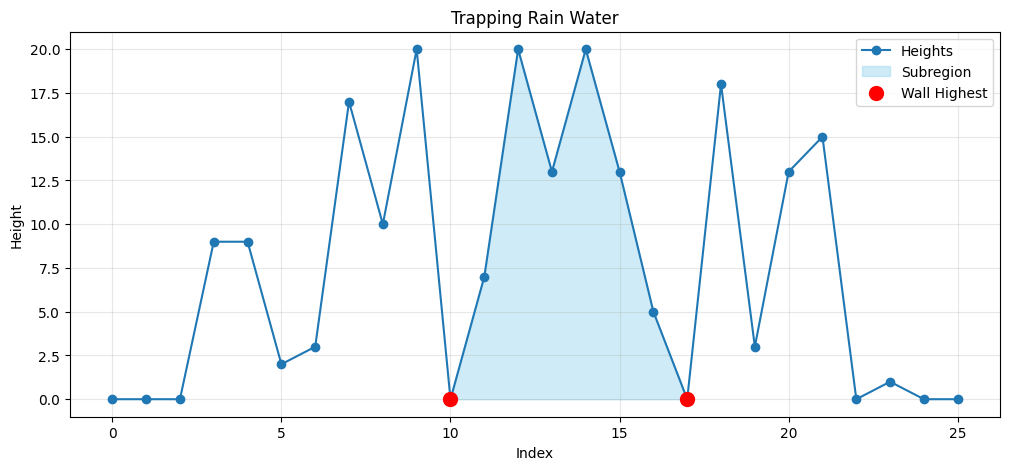

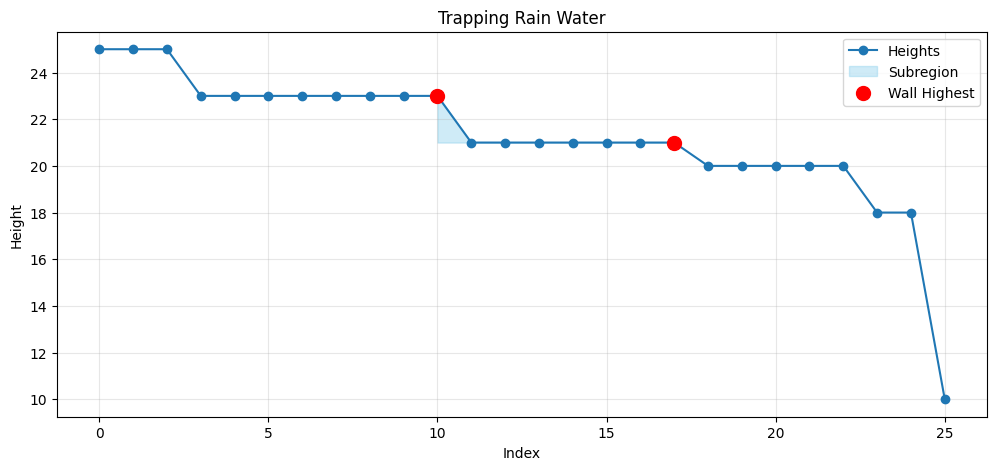

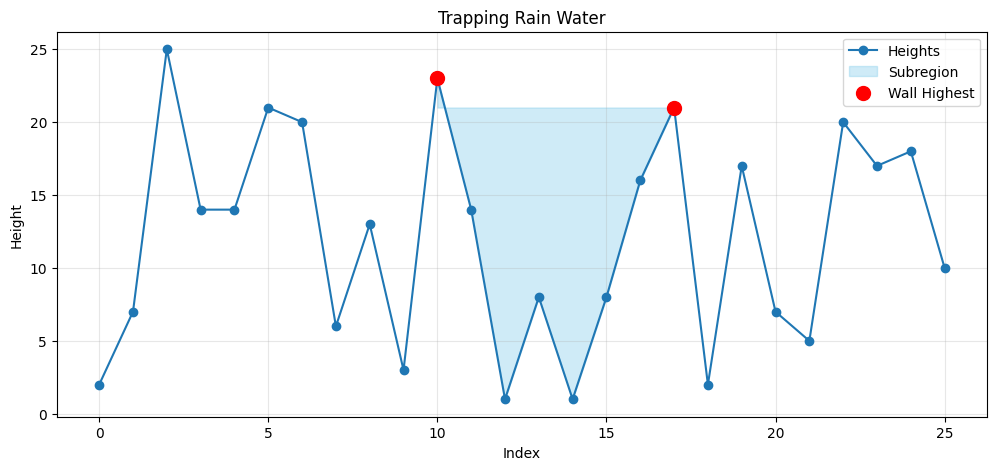

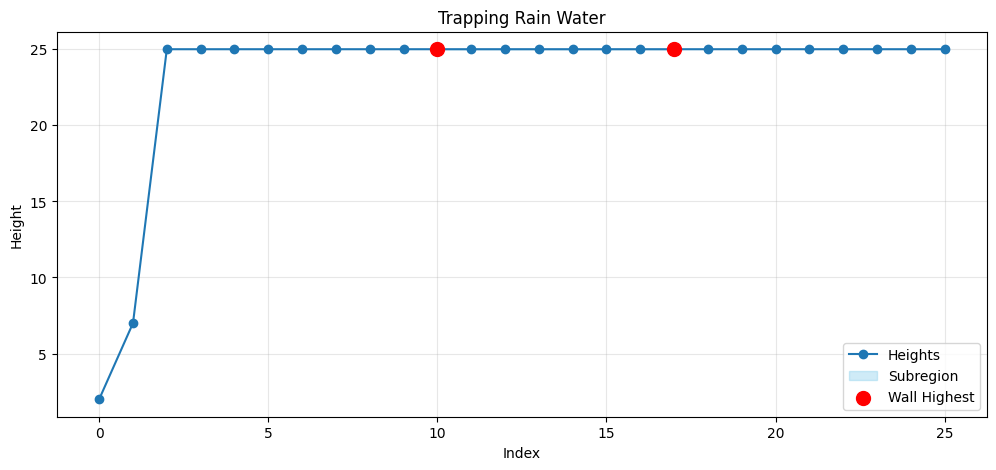

In [ ]:
def calculate_deaph_level(arr):
    if len(arr) < 3:
        return 0
    
    left_wall = np.maximum.accumulate(arr)
    right_wall = np.maximum.accumulate(arr[::-1])[::-1] 
    water_level = np.minimum(left_wall, right_wall) - arr

    return water_level

water_level = calculate_deaph_level(example_data)
left_wall = np.maximum.accumulate(example_data)
right_wall = np.maximum.accumulate(example_data[::-1])[::-1] 

# Table format output
print("Index | Height | Left Max | Right Max | Water")
print("-" * 50)
for i in range(len(example_data)):
    print(f"{i:5} | {example_data[i]:6} | {left_wall[i]:8} | {right_wall[i]:9} | {water_level[i]:5}")
visualize_with_highlights(water_level, start_idx=10, end_idx=18, highest_idxs=[10, 17])
visualize_with_highlights(right_wall, start_idx=10, end_idx=18, highest_idxs=[10, 17])
visualize_with_highlights(example_data, start_idx=10, end_idx=18, highest_idxs=[10, 17])
visualize_with_highlights(left_wall, start_idx=10, end_idx=18, highest_idxs=[10, 17])

# works rnd

Index | Height | Left Max | Right Max | Water
--------------------------------------------------
    0 |     19 |       19 |        25 |     0
    1 |     25 |       25 |        25 |     0
    2 |      7 |       25 |        24 |    17
    3 |     10 |       25 |        24 |    14
    4 |      2 |       25 |        24 |    22
    5 |     10 |       25 |        24 |    14
    6 |     21 |       25 |        24 |     3
    7 |     11 |       25 |        24 |    13
    8 |      1 |       25 |        24 |    23
    9 |     19 |       25 |        24 |     5
   10 |     20 |       25 |        24 |     4
   11 |     24 |       25 |        24 |     0
   12 |      9 |       25 |        24 |    15
   13 |     22 |       25 |        24 |     2
   14 |     16 |       25 |        24 |     8
   15 |     24 |       25 |        24 |     0
   16 |      6 |       25 |        22 |    16
   17 |      3 |       25 |        22 |    19
   18 |      9 |       25 |        22 |    13
   19 |      6 |       25 |  

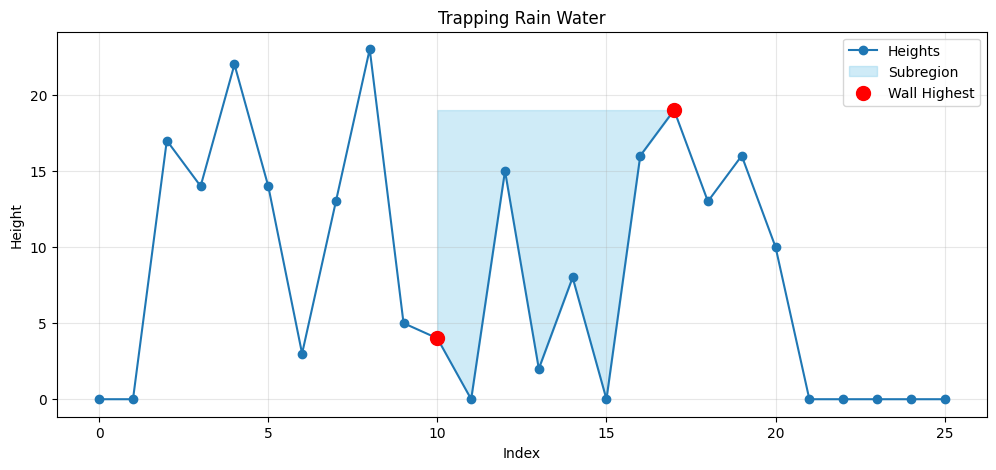

In [ ]:

water_level = calculate_deaph_level(rnd_data)
left_wall = np.maximum.accumulate(rnd_data)
right_wall = np.maximum.accumulate(rnd_data[::-1])[::-1] 

# Table format output
print("Index | Height | Left Max | Right Max | Water")
print("-" * 50)
for i in range(len(rnd_data)):
    print(f"{i:5} | {rnd_data[i]:6} | {left_wall[i]:8} | {right_wall[i]:9} | {water_level[i]:5}")
visualize_with_highlights(water_level, start_idx=10, end_idx=18, highest_idxs=[10, 17])
visualize_with_highlights(right_wall, start_idx=10, end_idx=18, highest_idxs=[10, 17])
visualize_with_highlights(rnd_data, start_idx=10, end_idx=18, highest_idxs=[10, 17])
visualize_with_highlights(left_wall, start_idx=10, end_idx=18, highest_idxs=[10, 17])